# Validation of the Bipartite Network
https://bipartite-configuration-model.readthedocs.io/en/latest/

In [1]:
pip install bicm

  Using cached bicm-3.4.0-py3-none-any.whl.metadata (4.9 kB)
Using cached bicm-3.4.0-py3-none-any.whl (32 kB)
Note: you may need to restart the kernel to use updated packages.


In [2]:
from scipy.sparse import csr_matrix
from bicm import BipartiteGraph

import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from tqdm import tqdm
import re

In [3]:
import matplotlib as mpl

# Enable LaTeX-style font
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'

## 02 Load Data

In [4]:
edge_list = pd.read_csv('../02_data/train_test/train_edge_list.csv')
train_data = pd.read_csv('../02_data/train_test/train_data.csv')

In [5]:
edge_list.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4110445 entries, 0 to 4110444
Data columns (total 2 columns):
 #   Column     Dtype
---  ------     -----
 0   chat_id    int64
 1   domain_id  int64
dtypes: int64(2)
memory usage: 62.7 MB


In [6]:
#edge_list["domain_id"] = edge_list["domain_id"].astype(str).str.strip()
#edge_list["domain_id"] = pd.to_numeric(edge_list["domain_id"], errors="coerce")
#edge_list = edge_list.dropna()
edge_list = edge_list.astype(int)
edge_list = edge_list.reset_index(drop=True)

In [7]:
print('unique chats:', len(edge_list["chat_id"].unique()))
print('unique domains:', len(edge_list["domain_id"].unique()))

unique chats: 24658
unique domains: 4829


In [8]:
from itertools import combinations
from collections import Counter

# group domains by chat
grouped = edge_list.groupby("chat_id")["domain_id"].apply(list)

# pairs of co-occurring domains per chat
cooccurrence_pairs = []
for domains in grouped:
    pairs = combinations(sorted(set(domains)), 2)
    cooccurrence_pairs.extend(pairs)

# count co-occurrences
cooccurrence_counts = Counter(cooccurrence_pairs)

In [9]:
#cooccurrence_counts[:10]

## 03 Validation

In [10]:
# extract unique row (chat) and column (domain) nodes
chat_nodes = sorted(edge_list['chat_id'].unique())   # Row nodes (layer True)
domain_nodes = sorted(edge_list['domain_id'].unique())  # Column nodes (layer False)

# index mapping for fast lookup
chat_to_idx = {chat: i for i, chat in enumerate(chat_nodes)}
domain_to_idx = {domain: i for i, domain in enumerate(domain_nodes)}

# row and column indices for the biadjacency matrix
row_indices = edge_list['chat_id'].map(chat_to_idx).to_numpy()
col_indices = edge_list['domain_id'].map(domain_to_idx).to_numpy()

# sparse biadjacency matrix (binary)
biadj_matrix = csr_matrix((np.ones(len(row_indices), dtype=int), (row_indices, col_indices)),
                          shape=(len(chat_nodes), len(domain_nodes)))

# dense NumPy array
biadj_matrix_dense = biadj_matrix.toarray()

print(f"Biadjacency Matrix Shape (Chats, Domains): {biadj_matrix.shape}")
print(biadj_matrix_dense[:10, :10]) 

Biadjacency Matrix Shape (Chats, Domains): (24658, 4829)
[[0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]]


In [11]:
myGraph = BipartiteGraph()
myGraph.set_edgelist(edge_list.to_numpy())
#myGraph.set_biadjacency_matrix(biadj_matrix)
myGraph

In [12]:
temp = myGraph.get_cols_projection(alpha=0.1, method='poisson', threads_num=4, progress_bar=True, fmt='edgelist') # monopartite network of domains
# co-occurrences of domains in the same chat
# correcting the projection on statistical significance level of 95%

First I have to compute the BiCM. Computing...


/opt/conda/lib/python3.11/site-packages/numba/core/utils.py:554: NumbaExperimentalFeatureWarning: First-class function type feature is experimental
  warnings.warn("First-class function type feature is experimental",
/opt/conda/lib/python3.11/site-packages/bicm/models_functions.py:326: NumbaExperimentalFeatureWarning: First-class function type feature is experimental
  step_fun = args[0]
/opt/conda/lib/python3.11/site-packages/bicm/models_functions.py:327: NumbaExperimentalFeatureWarning: First-class function type feature is experimental
  arg_step_fun = args[1]
/opt/conda/lib/python3.11/site-packages/numba/core/utils.py:554: NumbaExperimentalFeatureWarning: First-class function type feature is experimental
  warnings.warn("First-class function type feature is experimental",


max rows error = 4.530875230557285e-08
max columns error = 1.2973578122910112e-07
total error = 7.666946356899018e-06
Solver converged.


100%|██████████| 4829/4829 [02:32<00:00, 31.65it/s]


In [13]:
my_probability_matrix = myGraph.get_bicm_matrix() 
my_x, my_y = myGraph.get_bicm_fitnesses()

In [14]:
my_probability_matrix

array([[7.56103499e-03, 7.95822545e-04, 5.06613551e-01, ...,
        3.97906594e-04, 3.97906594e-04, 2.78551346e-03],
       [6.18226557e-04, 6.46655095e-05, 7.69573565e-02, ...,
        3.23205494e-05, 3.23205494e-05, 2.26755059e-04],
       [7.87054488e-06, 8.22796465e-07, 1.05964385e-03, ...,
        4.11229800e-07, 4.11229800e-07, 2.88566696e-06],
       ...,
       [2.47478675e-04, 2.58772780e-05, 3.22852949e-02, ...,
        1.29335038e-05, 1.29335038e-05, 9.07496799e-05],
       [6.54472328e-04, 6.84589825e-05, 8.11060329e-02, ...,
        3.42166348e-05, 3.42166348e-05, 2.40054909e-04],
       [1.08059921e-04, 1.12977309e-05, 1.43563374e-02, ...,
        5.64658232e-06, 5.64658232e-06, 3.96217462e-05]])

In [15]:
temp.shape

(350883, 2)

In [16]:
temp

array([[1270, 5187],
       [1270, 5232],
       [1270, 5266],
       ...,
       [ 147,  390],
       [ 147, 4372],
       [ 940, 3887]])

In [17]:
W_uv = np.zeros((len(my_x), len(my_x)))
for x in temp:
    W_uv[x[0], x[1]] = 1
    W_uv[x[1], x[0]] = 1

In [18]:
W_uv.shape

(24658, 24658)

In [19]:
G_valid = nx.Graph()
G_valid.add_edges_from(temp)
pc1_dict = dict(zip(train_data["domain_id"], train_data["pc1"]))
nx.set_node_attributes(G_valid, pc1_dict, "pc1")

In [20]:
G = G_valid

In [21]:
num_nodes = G.number_of_nodes()
print(f"Number of nodes: {num_nodes}")

num_edges = G.number_of_edges()
print(f"Number of edges: {num_edges}")

degrees = [d for n, d in G.degree()]
avg_degree = sum(degrees) / num_nodes
print(f"Average degree: {avg_degree:.2f}")

max_degree = max(degrees)
min_degree = min(degrees)
print(f"Degree range: {min_degree} -- {max_degree}")

density = nx.density(G)
print(f"Density: {density:.4f}")

assortativity = nx.degree_assortativity_coefficient(G)
print(f"Assortativity coefficient: {assortativity:.4f}")

data = {
    "Measurement": [
        "Nodes",
        "Edges",
        "Average Degree",
        "Degree Range",
        "Density",
        "Assortativity Coefficient"
    ],
    "Value": [
        num_nodes,
        num_edges,
        f"{avg_degree:.2f}",
        f"{min_degree} -- {max_degree}",
        f"{density:.4f}",
        f"{assortativity:.4f}"
    ]
}

df = pd.DataFrame(data)

latex_table = df.to_latex(
    index=False,
    caption="Network summary statistics.",
    label="tab:network_statistics",
    column_format="|l|c|",
    longtable=False,
    escape=False
)

print("\nGenerated LaTeX table:\n")
print(latex_table)

# Optional: save to a .tex file
with open("network_statistics_table.tex", "w") as f:
    f.write(latex_table)
    print("\nLaTeX table saved to 'network_statistics_table.tex'")

Number of nodes: 4574
Number of edges: 350883
Average degree: 153.43
Degree range: 1 -- 935
Density: 0.0336
Assortativity coefficient: 0.3860

Generated LaTeX table:

\begin{table}
\caption{Network summary statistics.}
\label{tab:network_statistics}
\begin{tabular}{|l|c|}
\toprule
Measurement & Value \\
\midrule
Nodes & 4574 \\
Edges & 350883 \\
Average Degree & 153.43 \\
Degree Range & 1 -- 935 \\
Density & 0.0336 \\
Assortativity Coefficient & 0.3860 \\
\bottomrule
\end{tabular}
\end{table}


LaTeX table saved to 'network_statistics_table.tex'


In [22]:
quality_dict = dict(zip(train_data['domain_id'], train_data["pc1"]))
G = G.subgraph([n for n in G.nodes if n in quality_dict]).copy()
nx.set_node_attributes(G, quality_dict, name='quality')
r = nx.numeric_assortativity_coefficient(G, attribute='quality')
print(f"Quality assortativity coefficient (based on 'pc1'): {r:.4f}")


Quality assortativity coefficient (based on 'pc1'): 0.2246


## 04 Plots

In [23]:
# Compute node degrees
degree_dict = dict(G_valid.degree())

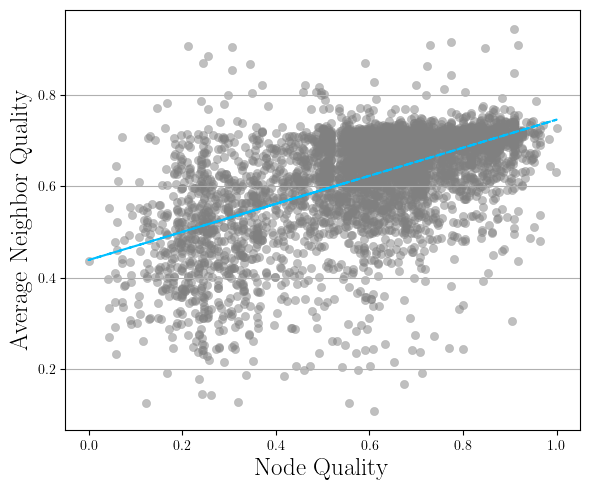

In [43]:
# Extract nodes with a defined quality
nodes = [n for n in G.nodes if 'quality' in G.nodes[n]]

x = []  # node's own quality
y = []  # average neighbor quality

for node in nodes:
    neighbors = list(G.neighbors(node))
    if not neighbors:
        continue  # skip isolated nodes

    # Get quality of neighbors (filter out any without quality)
    neighbor_qualities = [
        G.nodes[nb]['quality']
        for nb in neighbors
        if 'quality' in G.nodes[nb]
    ]
    if not neighbor_qualities:
        continue  # skip if neighbors have no quality

    x.append(G.nodes[node]['quality'])
    y.append(np.mean(neighbor_qualities))

# Create the scatter plot
plt.figure(figsize=(6, 5))
plt.scatter(x, y, alpha=0.5, linewidths=0.3, color='grey') #, edgecolors='k'
plt.xlabel("Node Quality", fontsize=18)
plt.ylabel("Average Neighbor Quality", fontsize=18)
# plt.title("Node Quality vs. Average Neighbor Quality")
plt.grid(axis='y')

# Optional: fit regression line
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*np.array(x) + b, color='deepskyblue', linestyle='--') #, label='Trend line'
#plt.legend()

plt.tight_layout()
plt.savefig('../03_plots/neighbor_assortativity.pdf')
plt.show()


Top 50% degree threshold: 95.5
Filtered nodes count: 2287
Subgraph node count: 2287
Size of node_colors array: 2287


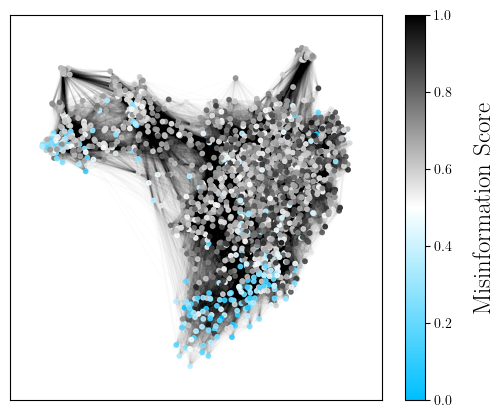

In [45]:
from matplotlib.colors import LinearSegmentedColormap

G_valid = nx.Graph()
G_valid.add_edges_from(temp)
pc1_dict = dict(zip(train_data["domain_id"], train_data["pc1"]))
nx.set_node_attributes(G_valid, pc1_dict, "pc1")

# node degrees
degree_dict = dict(G_valid.degree())

# degree threshold
degree_threshold = np.percentile(list(degree_dict.values()), 50)
filtered_nodes = [node for node, deg in degree_dict.items() if deg >= degree_threshold]

# debugging
print(f"Top 50% degree threshold: {degree_threshold}")
print(f"Filtered nodes count: {len(filtered_nodes)}")

# subgraph
subgraph = G_valid.subgraph(filtered_nodes)

# Extract PC1 values for all nodes in the subgraph
pc1_values = np.array([pc1_dict.get(node, 0) for node in subgraph.nodes()])


from matplotlib.colors import LinearSegmentedColormap

# Custom colormap: 0 -> deepskyblue, 1 -> white
custom_cmap = LinearSegmentedColormap.from_list("custom_blue_white", ["deepskyblue", "white", "black"])

# Normalize PC1 values between 0 and 1
norm = plt.Normalize(vmin=0, vmax=1)
node_colors = custom_cmap(norm(pc1_values))

# colors
# norm = plt.Normalize(vmin=min(pc1_values), vmax=max(pc1_values))
# cmap = plt.cm.RdBu
# node_colors = cmap(norm(pc1_values))

print(f"Subgraph node count: {len(subgraph.nodes())}")
print(f"Size of node_colors array: {len(node_colors)}")

# network plot
fig, ax = plt.subplots(figsize=(6, 5))
#ax.axis('off')
pos = nx.spring_layout(subgraph, k=0.01, seed=42)

nodes = nx.draw_networkx_nodes(subgraph, pos, node_size=10, alpha=0.9, node_color=node_colors, cmap=custom_cmap, ax=ax)
nx.draw_networkx_edges(subgraph, pos, alpha=0.01, ax=ax)

# colorbar
sm = plt.cm.ScalarMappable(cmap=custom_cmap, norm=norm)
sm.set_array([])  # Required for colorbar to work
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("Misinformation Score", labelpad=15)
cbar.ax.yaxis.label.set_size(18)
#fig.colorbar(sm, ax=ax, label="Misinformation Score")

#plt.title("Top 50% Nodes by Degree", fontsize=14)
#plt.title("Validated Chat-Domain Subnetwork", fontsize=20)

# plt.title("Projection of the bipartite network of chats and domains (Top 25% Nodes by Degree, Colored by PC1)")
plt.savefig('../03_plots/degree_network_colored_50.png')
plt.show()


In [ ]:
pc1_values = np.array([pc1_dict.get(node, 0) for node in G_valid.nodes()])

# Normalize colors
norm = plt.Normalize(vmin=min(pc1_values), vmax=max(pc1_values))
cmap = plt.cm.RdBu
node_colors = cmap(norm(pc1_values))

# Debugging: Ensure node_colors and subgraph size match
print(f"Subgraph node count: {len(G_valid.nodes())}")
print(f"Size of node_colors array: {len(node_colors)}")

# Create figure and axis
fig, ax = plt.subplots(figsize=(14, 10))

# Compute layout
pos = nx.spring_layout(G_valid, k=0.1, seed=42)

# Draw network plot
nodes = nx.draw_networkx_nodes(G_valid, pos, node_size=10, alpha=0.9, node_color=node_colors, cmap=cmap, ax=ax)
nx.draw_networkx_edges(G_valid, pos, alpha=0.05, ax=ax)

# Add colorbar properly linked to the figure
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # Required for colorbar to work
fig.colorbar(sm, ax=ax, label="PC1 Value")

# Add title and save
plt.title("Validated Chat-Domain-Network")
plt.savefig('../03_plots/degree_network_colored_full.png')
plt.show()

In [ ]:
np.save("../02_data/train_test/validated_edges.npy", temp)
#np.save("../02_data/content_agnostic/validated_adjecency_matrix.npy", W_uv)